## 1. Data Acquisition

In [13]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
import numpy as np

In [14]:
files = sorted(glob.glob("all_batting/batting_part_*.csv"))
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
print(df.shape)

/var/folders/7y/c8_smbxj3v13gsc7ld8064h80000gn/T/ipykernel_42639/2110351657.py:2: DtypeWarning: Columns (0: Unnamed: 39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)


(5746326, 89)


## 2. Data Cleaning

In [15]:
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print(df[df['gid'].isnull()].shape)
print(df[df['gid'].isnull()].head())

(746327, 85)
         gid   id team  b_lp  b_seq stattype  b_pa  b_ab  b_r  b_h  ...  y.1  \
4999999  NaN  NaN  NaN   NaN    NaN      NaN   NaN   NaN  NaN  NaN  ...    y   
5000000  NaN  NaN  NaN   NaN    NaN      NaN   NaN   NaN  NaN  NaN  ...    y   
5000001  NaN  NaN  NaN   NaN    NaN      NaN   NaN   NaN  NaN  NaN  ...    y   
5000002  NaN  NaN  NaN   NaN    NaN      NaN   NaN   NaN  NaN  NaN  ...    y   
5000003  NaN  NaN  NaN   NaN    NaN      NaN   NaN   NaN  NaN  NaN  ...    y   

         ARI201208110  wheer001  ARI   9  20120811  PHO01    h  WAS  1.6  
4999999           NaN       NaN  NaN NaN       NaN    NaN  NaN  NaN  NaN  
5000000           NaN       NaN  NaN NaN       NaN    NaN  NaN  NaN  NaN  
5000001           NaN       NaN  NaN NaN       NaN    NaN  NaN  NaN  NaN  
5000002           NaN       NaN  NaN NaN       NaN    NaN  NaN  NaN  NaN  
5000003           NaN       NaN  NaN NaN       NaN    NaN  NaN  NaN  NaN  

[5 rows x 85 columns]


In [16]:
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
df = df.dropna(subset=['gid'])
print(df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

(4999999, 85)
b_lp         405212
b_seq        402149
b_pa          47704
b_ab          15116
b_r           13863
             ...   
20120811    4999999
PHO01       4999999
h           4999999
WAS         4999999
1.6         4999999
Length: 73, dtype: int64


In [17]:
df = df[df['b_ab'] > 0]
print(df.shape)

(4024655, 85)


In [18]:
print(df.columns.tolist())
print(df.shape)

['gid', 'id', 'team', 'b_lp', 'b_seq', 'stattype', 'b_pa', 'b_ab', 'b_r', 'b_h', 'b_d', 'b_t', 'b_hr', 'b_rbi', 'b_sh', 'b_sf', 'b_hbp', 'b_w', 'b_iw', 'b_k', 'b_sb', 'b_cs', 'b_gdp', 'b_xi', 'b_roe', 'dh', 'ph', 'pr', 'date', 'number', 'site', 'vishome', 'opp', 'win', 'loss', 'tie', 'gametype', 'box', 'pbp', 'eject', 'BOS194108061', 'sturj101', 'NYA', '1', '1.1', 'value', '4', '3', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '1.2', '0.9', '0.10', '0.11', '0.12', '1.3', '0.13', '0.14', '19410806', '1.4', 'BOS07', 'v', 'BOS', '0.15', '1.5', '0.16', 'regular', 'y', 'y.1', 'ARI201208110', 'wheer001', 'ARI', '9', '20120811', 'PHO01', 'h', 'WAS', '1.6']
(4024655, 85)


In [19]:
good_cols = ['gid', 'id', 'team', 'b_lp', 'b_seq', 'stattype', 'b_pa', 'b_ab', 'b_r', 'b_h', 
             'b_d', 'b_t', 'b_hr', 'b_rbi', 'b_sh', 'b_sf', 'b_hbp', 'b_w', 'b_iw', 'b_k', 
             'b_sb', 'b_cs', 'b_gdp', 'b_xi', 'b_roe', 'dh', 'ph', 'pr', 'date', 'number', 
             'site', 'vishome', 'opp', 'win', 'loss', 'tie', 'gametype', 'box', 'pbp', 'eject']

df = df[good_cols]
print(df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

(4024655, 40)
b_lp         3654
b_seq        3577
b_pa        30967
b_r          1789
b_h           443
b_d          5522
b_t          5850
b_hr         4661
b_rbi       46645
b_sh         9000
b_sf       238734
b_hbp       10499
b_w          8420
b_iw       224043
b_k        112862
b_sb         8673
b_cs       250036
b_gdp      254586
b_xi        46075
b_roe      281549
dh        3899543
ph        3664399
pr        4010200
number     171135
box          4082
pbp        268026
eject     4017244
dtype: int64


In [20]:
df = df.drop(columns=['eject', 'pr', 'ph', 'dh', 'box', 'pbp'])
stat_cols = ['b_pa', 'b_r', 'b_h', 'b_d', 'b_t', 'b_hr', 'b_rbi', 'b_sh', 
             'b_sf', 'b_hbp', 'b_w', 'b_iw', 'b_k', 'b_sb', 'b_cs', 
             'b_gdp', 'b_xi', 'b_roe', 'b_lp', 'b_seq']
df[stat_cols] = df[stat_cols].fillna(0)
df['number'] = df['number'].fillna(0)
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [21]:
print(df['date'].astype(str).str[:4].min())

1898


In [22]:
df['year'] = df['date'].astype(int).astype(str).str[:4].astype(int)
df_early = df[df['year'] <= 1950]
df_mid = df[(df['year'] >= 1951) & (df['year'] <= 1990)]
df_contemporary = df[df['year'] >= 1991]
print(df_early.shape)
print(df_mid.shape)
print(df_contemporary.shape)

(1233120, 35)
(1302156, 35)
(1489379, 35)


In [25]:
df1 = pd.read_csv("Project/mlb_teams.csv")
df_teams = df1.dropna(subset=['team_name'])
df_teams = df1[df1['games_played'] > 0]
print(df_teams.shape)
print(df_teams.isnull().sum()[df_teams.isnull().sum() > 0])

(2784, 41)
division_id              1346
home_games                228
division_winner          1374
wild_card_winner         2010
league_winner              28
world_series_winner       248
strikeouts_by_batters      16
stolen_bases               76
caught_stealing           708
batters_hit_by_pitch     1066
sacrifice_flies          1370
home_attendance           108
dtype: int64


In [26]:
flag_cols = ['division_winner', 'wild_card_winner', 'league_winner', 'world_series_winner']
df_teams[flag_cols] = df_teams[flag_cols].fillna('N')
num_cols = ['home_games', 'strikeouts_by_batters', 'stolen_bases', 'caught_stealing', 
            'batters_hit_by_pitch', 'sacrifice_flies', 'home_attendance']
df_teams[num_cols] = df_teams[num_cols].fillna(0)
df_teams['division_id'] = df_teams['division_id'].fillna('Unknown')
print(df_teams.isnull().sum()[df_teams.isnull().sum() > 0])

Series([], dtype: int64)


In [27]:
print(df_teams.isnull().sum().sum())

0


In [28]:
df_teams['year'].min(), df_teams['year'].max()

(np.int64(1876), np.int64(2020))

In [29]:
df_teams_early = df_teams[df_teams['year'] <= 1950]
df_teams_mid = df_teams[(df_teams['year'] >= 1951) & (df_teams['year'] <= 1990)]
df_teams_contemporary = df_teams[df_teams['year'] >= 1991]

print(df_teams_early.shape)
print(df_teams_mid.shape)
print(df_teams_contemporary.shape)

(1028, 41)
(874, 41)
(882, 41)


## 3. Data Integration 

In [31]:
df_yearly = df.groupby('year').agg(
    total_ab=('b_ab', 'sum'),
    total_hits=('b_h', 'sum'),
    total_hr=('b_hr', 'sum'),
    total_runs=('b_r', 'sum'),
    total_rbi=('b_rbi', 'sum'),
    total_walks=('b_w', 'sum'),
    total_k=('b_k', 'sum'),
    total_sb=('b_sb', 'sum'),
).reset_index()
df_teams_yearly = df_teams.groupby('year').agg(
    total_wins=('wins', 'sum'),
    total_losses=('losses', 'sum'),
    total_runs_scored=('runs_scored', 'sum'),
    total_hr=('homeruns', 'sum'),
    total_errors=('errors', 'sum'),
    total_attendance=('home_attendance', 'sum'),
    num_teams=('team_name', 'count')
).reset_index()

print(df_yearly.head())
print(df_teams_yearly.head())

   year  total_ab  total_hits  total_hr  total_runs  total_rbi  total_walks  \
0  1898   55224.0     15022.0     263.0      8134.0     6703.0       4525.0   
1  1899   55188.0     15591.0     312.0      8508.0     7017.0       4266.0   
2  1900   34786.0      9721.0     235.0      5239.0     4309.0       2664.0   
3  1901   71176.0     19245.0     433.0     10235.0     8311.0       5141.0   
4  1902   70090.0     18790.0     340.0      9155.0     7501.0       5024.0   

   total_k  total_sb  
0   3015.0    1908.0  
1   2811.0    2401.0  
2   2191.0    1525.0  
3   5231.0    2665.0  
4   4965.0    2518.0  
   year  total_wins  total_losses  total_runs_scored  total_hr  total_errors  \
0  1876         257           257               3066        40          3124   
1  1877         177           177               2040        24          1858   
2  1878         180           180               1904        23          1778   
3  1879         316           316               3409        58     

In [32]:
df_combined = pd.merge(df_yearly, df_teams_yearly, on='year', how='inner') 
print(df_combined.shape) 
print(df_combined.head())

(123, 16)
   year  total_ab  total_hits  total_hr_x  total_runs  total_rbi  total_walks  \
0  1898   55224.0     15022.0       263.0      8134.0     6703.0       4525.0   
1  1899   55188.0     15591.0       312.0      8508.0     7017.0       4266.0   
2  1900   34786.0      9721.0       235.0      5239.0     4309.0       2664.0   
3  1901   71176.0     19245.0       433.0     10235.0     8311.0       5141.0   
4  1902   70090.0     18790.0       340.0      9155.0     7501.0       5024.0   

   total_k  total_sb  total_wins  total_losses  total_runs_scored  total_hr_y  \
0   3015.0    1908.0         897           897               9129         299   
1   2811.0    2401.0         903           903               9672         352   
2   2191.0    1525.0         554           554               5932         254   
3   5231.0    2665.0        1095          1095              11067         455   
4   4965.0    2518.0        1093          1093               9901         354   

   total_errors 

## 4a. Summary Statistics
Aggregating to player-season level

In [35]:
player_season = df.groupby(['id', 'year']).agg(
    games   = ('gid',  'nunique'),
    ab      = ('b_ab', 'sum'),
    hits    = ('b_h',  'sum'),
    hr      = ('b_hr', 'sum'),
    doubles = ('b_d', 'sum'),
    triples = ('b_t', 'sum'),
    rbi     = ('b_rbi','sum'),
    walks   = ('b_w',  'sum'),
    k       = ('b_k',  'sum'),
    sb      = ('b_sb', 'sum'),
).reset_index()

player_season = player_season[player_season['ab'] >= 50].copy()

player_season['avg'] = (player_season['hits'] / player_season['ab']).round(3)

combined_cols = [
    'year',
    'total_wins',    
    'total_errors',
    'total_attendance', 
    'num_teams',     
]
player_season = player_season.merge(
    df_combined[combined_cols],
    on='year',
    how='left'
)

print(player_season.shape)
print('Columns:', player_season.columns.tolist())
player_season.head()

(44841, 17)
Columns: ['id', 'year', 'games', 'ab', 'hits', 'hr', 'doubles', 'triples', 'rbi', 'walks', 'k', 'sb', 'avg', 'total_wins', 'total_errors', 'total_attendance', 'num_teams']


,id,year,games,ab,hits,hr,doubles,triples,rbi,walks,k,sb,avg,total_wins,total_errors,total_attendance,num_teams
0,aaroh101,1954,121,468.0,131.0,13.0,27.0,6.0,69.0,27.0,39.0,2.0,0.280,1232.0,2270.0,15935883.0,16.0
1,aaroh101,1955,154,613.0,194.0,27.0,39.0,9.0,108.0,50.0,62.0,3.0,0.316,1231.0,2218.0,16617383.0,16.0
2,aaroh101,1956,154,614.0,201.0,26.0,34.0,15.0,93.0,37.0,54.0,2.0,0.327,1232.0,2243.0,16543250.0,16.0
3,aaroh101,1957,158,651.0,212.0,47.0,28.0,7.0,140.0,57.0,65.0,1.0,0.326,1230.0,2098.0,17015819.0,16.0
4,aaroh101,1958,161,630.0,205.0,30.0,36.0,4.0,98.0,64.0,55.0,4.0,0.325,1231.0,2080.0,17460630.0,16.0


In [38]:
print('League-level yearly summary (first 10 rows):')
print(df_combined[[
    'year',
    'total_ab', 'total_hits', 'total_hr_x',
    'total_runs', 'total_wins', 'total_errors',
    'total_attendance', 'num_teams'
]].head(10).to_string(index=False))

df_combined['league_avg'] = (df_combined['total_hits'] / df_combined['total_ab']).round(3)
print('\nLeague batting average range:')
print(f"  Min year: {df_combined['year'].min()}  Max year: {df_combined['year'].max()}")
print(f"  Avg BA range: {df_combined['league_avg'].min():.3f} – {df_combined['league_avg'].max():.3f}")

League-level yearly summary (first 10 rows):
 year  total_ab  total_hits  total_hr_x  total_runs  total_wins  total_errors  total_attendance  num_teams
 1898   55224.0     15022.0       263.0      8134.0         897          4387         2372089.0         12
 1899   55188.0     15591.0       312.0      8508.0         903          4457         2541485.0         12
 1900   34786.0      9721.0       235.0      5239.0         554          2757         1829490.0          8
 1901   71176.0     19245.0       433.0     10235.0        1095          5331         3603615.0         16
 1902   70090.0     18790.0       340.0      9155.0        1093          4749         3889466.0         16
 1903   69083.0     18150.0       316.0      9071.0        1099          4679         4735250.0         16
 1904   74331.0     18403.0       308.0      8420.0        1220          4704         5688299.0         16
 1905   73359.0     18255.0       311.0      8602.0        1218          4539         5855062.0    

## 4b. Visualizations

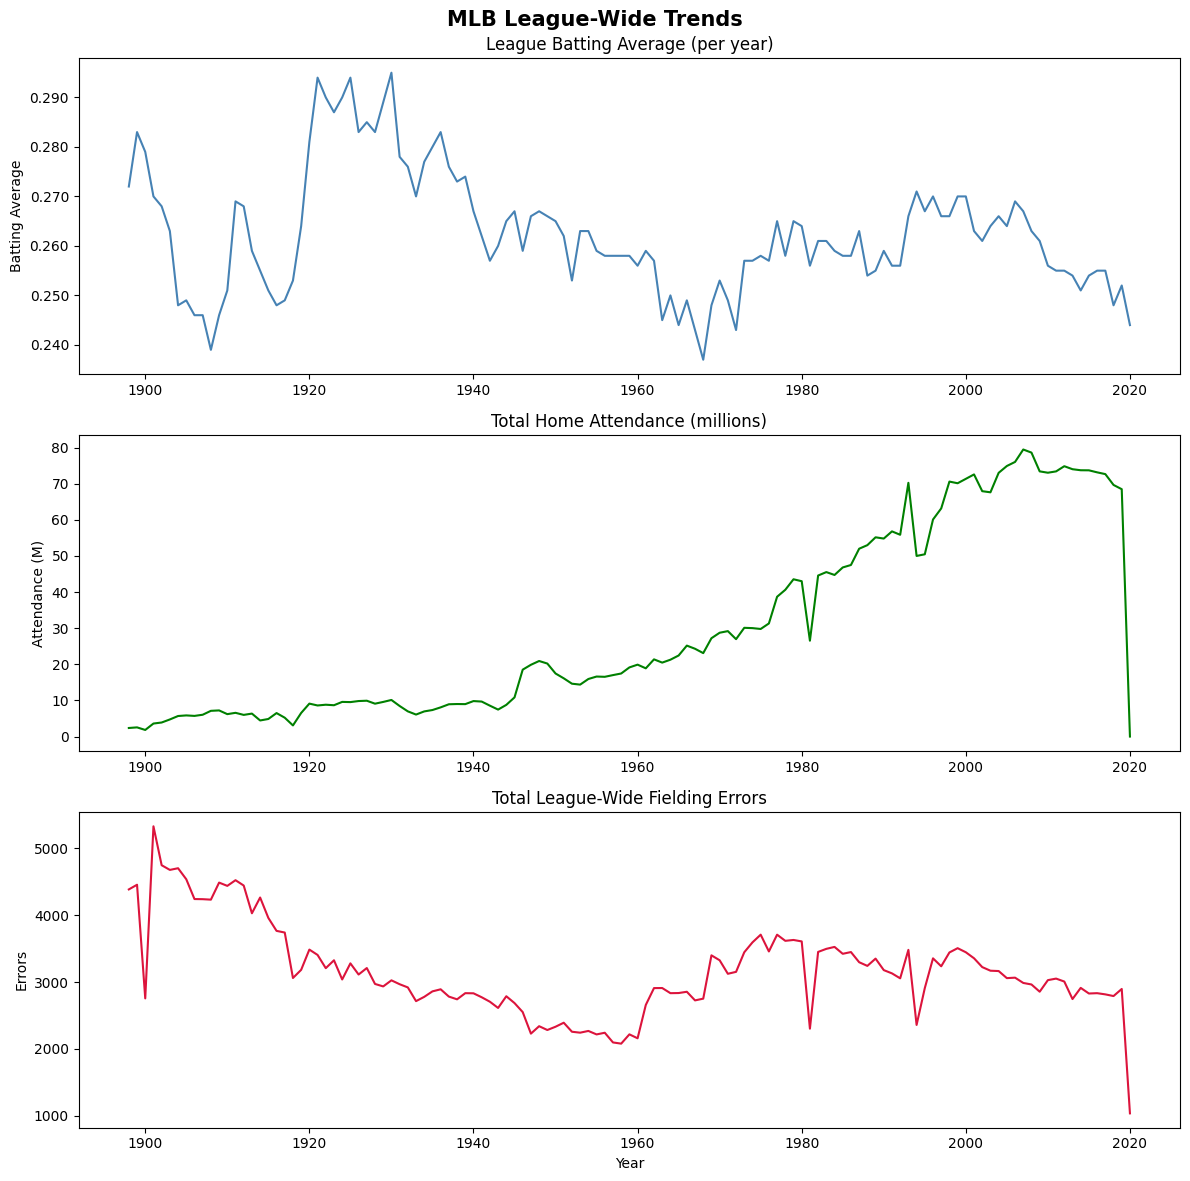

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle('MLB League-Wide Trends', fontsize=15, fontweight='bold')

# League batting average
axes[0].plot(df_combined['year'], df_combined['league_avg'], color='steelblue')
axes[0].set_title('League Batting Average (per year)')
axes[0].set_ylabel('Batting Average')
axes[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

# Total home attendance
axes[1].plot(df_combined['year'], df_combined['total_attendance'] / 1_000_000, color='green')
axes[1].set_title('Total Home Attendance (millions)')
axes[1].set_ylabel('Attendance (M)')

# Total errors (league-wide)
axes[2].plot(df_combined['year'], df_combined['total_errors'], color='crimson')
axes[2].set_title('Total League-Wide Fielding Errors')
axes[2].set_ylabel('Errors')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.savefig('league_trends_integrated.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Linear Regression Model

In [48]:
features = ['ab', 'games', 'hits', 'doubles', 'triples', 'rbi', 'walks', 'k', 'sb', 'num_teams', 'total_errors', 'total_attendance']
target   = 'hr'

model_df = player_season[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(f"R²  (train): {lr.score(X_train, y_train):.4f}")
print(f"R²  (test) : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE (test): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print()
print("Coefficients:")
for feat, coef in zip(features, lr.coef_):
    print(f"  {feat:>10}: {coef:.4f}")
print(f"  {'intercept':>10}: {lr.intercept_:.4f}")

R²  (train): 0.8466
R²  (test) : 0.8424
RMSE (test): 3.4401

Coefficients:
          ab: -0.0161
       games: -0.0377
        hits: 0.0296
     doubles: -0.1243
     triples: -0.3670
         rbi: 0.2903
       walks: 0.0403
           k: 0.0975
          sb: -0.0380
   num_teams: 0.0509
  total_errors: -0.0005
  total_attendance: -0.0000
   intercept: 0.0186


#### Visualization of Predicted vs. Actual Home Runs

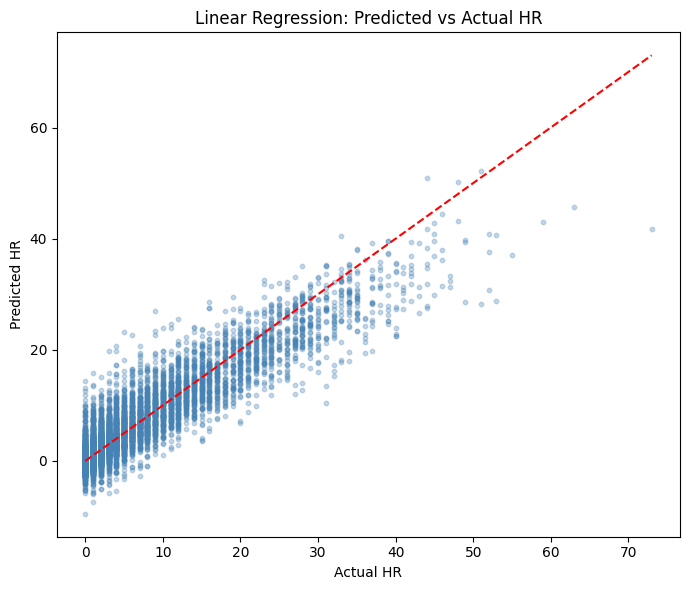

In [49]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
ax.set_xlabel('Actual HR')
ax.set_ylabel('Predicted HR')
ax.set_title('Linear Regression: Predicted vs Actual HR')
plt.tight_layout()
plt.savefig('lr_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Classification Model

In [50]:
model2_df = player_season[player_season['ab'] >= 100].copy()

model2_df['hit_10hr'] = (model2_df['hr'] >= 10).astype(int)

class_balance = model2_df['hit_10hr'].value_counts()
positive_rate = model2_df['hit_10hr'].mean()

print("Class Balance:", class_balance)
print("Positive Rate:", positive_rate)

Class Balance: hit_10hr
0    23097
1    10686
Name: count, dtype: int64
Positive Rate: 0.3163129384601723


In [51]:
features = ['ab', 'hits', 'doubles', 'triples', 'rbi', 'walks', 'k', 'sb', 'num_teams', 'total_errors', 'total_attendance']

classification_df = model2_df[features + ['hit_10hr']].dropna()

x = classification_df[features]
y = classification_df['hit_10hr']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

train_size = x_train.shape[0]
test_size = x_test.shape[0]

print("Training set size:", train_size)
print("Testing set size:", test_size)

Training set size: 25496
Testing set size: 6374


In [52]:
rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1)

rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Model Performance Metrics

In [55]:
y_pred = rf.predict(x_test)
y_proba = rf.predict_proba(x_test)[:, 1]

print(f"Random Forest Classifier Performance:")

class_report = classification_report(y_test, y_pred, target_names=['<10 HR', '≥10 HR'])
print("Classification Report:", class_report)

roc_auc = roc_auc_score(y_test, y_proba)
print("Roc AUC Score:", roc_auc)

Random Forest Classifier Performance:
Classification Report:               precision    recall  f1-score   support

      <10 HR       0.95      0.91      0.93      4428
      ≥10 HR       0.81      0.89      0.85      1946

    accuracy                           0.90      6374
   macro avg       0.88      0.90      0.89      6374
weighted avg       0.91      0.90      0.90      6374

Roc AUC Score: 0.9670639794784381
